# **👇👇👇Phase 1: Dataset Preparation👇👇👇**

Step 1: Mount Google Drive 👇

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CHECKING IF IT CONNECTS PROPERLY
import os
print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'IMG_20221114_102317.jpg', 'Prejudice.txt', 'Section-G, Roll no-6, Ramendra Raman Saha.pdf', 'Good.pdf', 'Ramendra Raman Saha, Section-G, Rollno-06.pdf', 'Ramendra Raman Saha ,roll 6 ,section G.pdf', '10930622011_Ramendra Raman Saha _G06.pdf', 'Ramendra Raman Saha G 22 (1).pdf', 'Ramendra Raman Saha G 22.pdf', '10930622011-AIML-RAMENDRA RAMAN SAHA (1).pdf', '10930622011-AIML-RAMENDRA RAMAN SAHA  (1).pdf', '10930622011-AIML-RAMENDRA RAMAN SAHA .pdf', '10930622011-AIML-RAMENDRA RAMAN SAHA.pdf', 'Introduction to GIT AND GITHUB.pdf', 'VOICE.pdf', 'ROTA CARNIVAL.pdf', 'ARDUINO.pdf', "GAMER'S HEAVEN.pdf", 'ROBOTICS WORKSHOP.pdf', 'GIT AND GITHUB.pdf', 'On The Page.pdf', 'TeXplorer.pdf', '10930622011_RamendraRamanSaha_AIML_2nd_A_11.pdf', '10930622011_Ramendra Raman Saha (5).pdf', '10930622011_Ramendra Raman Saha.pptx', 'WBJEE Result.pdf', '1ST SEMESTER RESULT.pdf', '2ND SEMESTER RESULT.pdf', 'Application for branch change.pdf', 'Screenshot_20230902_141708.jpg', '10930622011_Rame


FILE STRICTURE IN GOOGLE DRIVE
```
My Drive/
└── FINAL_YEAR_PROJECT/
    └── Drowsiness_dataset/
        │
        ├── Eye/
        │   ├── Open/
        │   └── Closed/
        │
        └── Mouth/
            ├── yawn/
            └── no_yawn/
```

Step 2: Import Libraries 👇

In [ ]:
!pip install tensorflow

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Step 3: Define Dataset Path 👇

In [ ]:
base_path = "/content/drive/MyDrive/FINAL_YEAR_PROJECT/Drowsiness_dataset"

eye_path = os.path.join(base_path, "Eye")
mouth_path = os.path.join(base_path, "Mouth")

Step 4: Check Folder Structure 👇

In [ ]:
print(os.listdir(base_path))

print(os.listdir(eye_path))
print(os.listdir(mouth_path))

['Eye', 'Mouth']
['Open', 'Closed']
['yawn', 'no_yawn']


Step 5: Count Images 👇

In [ ]:
print("Eye Dataset")

for folder in os.listdir(eye_path):
    print(folder, len(os.listdir(os.path.join(eye_path, folder))))

print()

print("Mouth Dataset")

for folder in os.listdir(mouth_path):
    print(folder, len(os.listdir(os.path.join(mouth_path, folder))))

Eye Dataset
Open 726
Closed 726

Mouth Dataset
yawn 723
no_yawn 725


***Load Eye Dataset***

Step 6





In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [ ]:
eye_train = tf.keras.preprocessing.image_dataset_from_directory(
    eye_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

eye_test = tf.keras.preprocessing.image_dataset_from_directory(
    eye_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1452 files belonging to 2 classes.
Using 1162 files for training.
Found 1452 files belonging to 2 classes.
Using 290 files for validation.


Step 7: Check Eye Labels 👇

In [ ]:
print(eye_train.class_names)

# Closed → 0
# Open → 1

['Closed', 'Open']



If you want
*   Open → 0
*   Closed → 1



```
eye_train = tf.keras.preprocessing.image_dataset_from_directory(
    eye_path,
    class_names=["Open","Closed"],
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

eye_test = tf.keras.preprocessing.image_dataset_from_directory(
    eye_path,
    class_names=["Open","Closed"],
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
```



***Load Mouth Dataset***

Step 8 👇

In [ ]:
mouth_train = tf.keras.preprocessing.image_dataset_from_directory(
    mouth_path,
    class_names=["no_yawn","yawn"],
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE

)

mouth_test = tf.keras.preprocessing.image_dataset_from_directory(
    mouth_path,
    class_names=["no_yawn","yawn"],
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1448 files belonging to 2 classes.
Using 1159 files for training.
Found 1448 files belonging to 2 classes.
Using 289 files for validation.


Step 9: Check Mouth Labels 👇

In [ ]:
print(mouth_train.class_names)

# No_Yawn → 0
# Yawn → 1

['no_yawn', 'yawn']


Step 10: Display Eye Images 👇

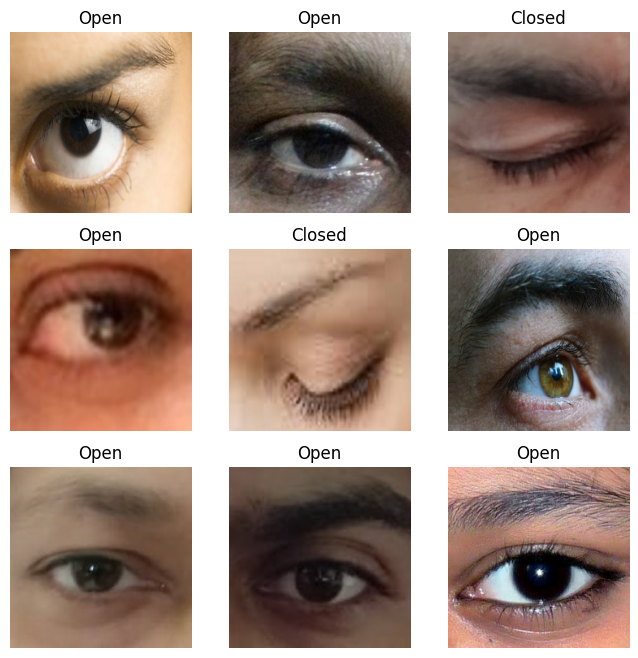

In [ ]:
plt.figure(figsize=(8,8))

for images,labels in eye_train.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(eye_train.class_names[labels[i]])
        plt.axis("off")

Step 11: Display Mouth Images 👇

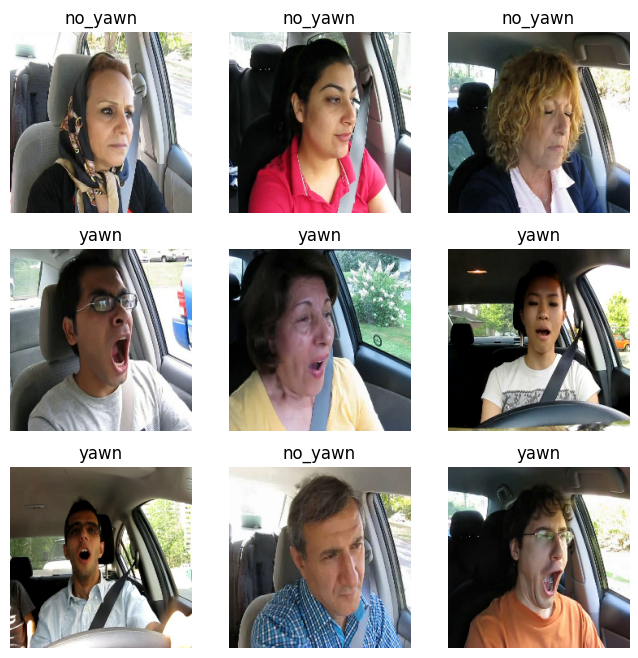

In [ ]:
plt.figure(figsize=(8,8))

for images,labels in mouth_train.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(mouth_train.class_names[labels[i]])
        plt.axis("off")

# 👇👇👇Phase 2: Image Preprocessing👇👇👇

Step 1: Resize

*   Already done while loading




In [ ]:
IMG_SIZE=(224,224)

Step 2: Convert to RGB

*  TensorFlow automatically converts to RGB.




In [ ]:
# verify for RGB, 3 means RGB
for images,labels in eye_train.take(1):
    print(images.shape)

(32, 224, 224, 3)


Step 3: Normalize

In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

eye_train = eye_train.map(
    lambda x,y:(normalization(x),y)
)

eye_test = eye_test.map(
    lambda x,y:(normalization(x),y)
)

mouth_train = mouth_train.map(
    lambda x,y:(normalization(x),y)
)

mouth_test = mouth_test.map(
    lambda x,y:(normalization(x),y)
)

Step 4: Verify Normalization

In [ ]:
for images,labels in eye_train.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())

0.0
0.8025911


Step 5: Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

Step 6: Apply Augmentation

In [ ]:
eye_train = eye_train.map(
    lambda x,y:
    (data_augmentation(x,training=True),y)
)

mouth_train = mouth_train.map(
    lambda x,y:
    (data_augmentation(x,training=True),y)
)

Step 7: Display Augmented Images

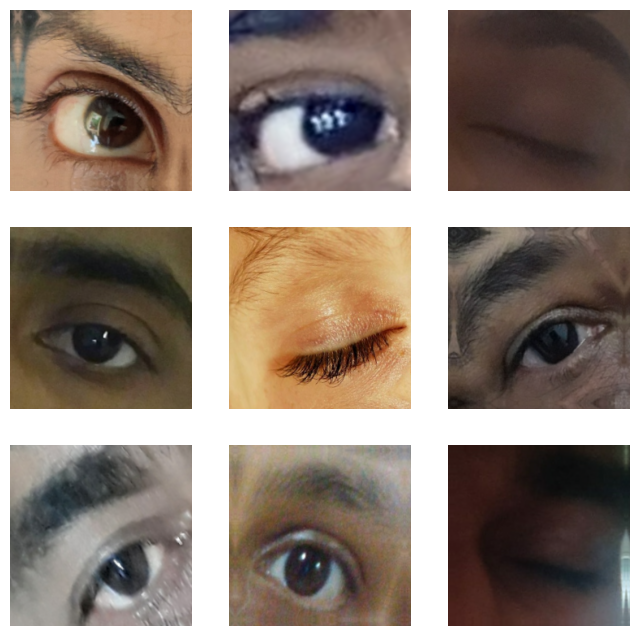

In [ ]:
for images,labels in eye_train.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.axis("off")
    break



```
here we are getting this warning
WARNING:matplotlib.image:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0137063].
WARNING:matplotlib.image:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.047785908..1.0451853].

*   If the warning appears only while plotting images with imshow(): No, this is normal.
*   If your model is training, it is generally better to ensure the final inputs stay in [0,1].

to eliminate this we use clipping after augmentation

eye_train = eye_train.map(
    lambda x, y: (
        tf.clip_by_value(data_augmentation(x, training=True), 0.0, 1.0),
        y
    )
)

mouth_train = mouth_train.map(
    lambda x, y: (
        tf.clip_by_value(data_augmentation(x, training=True), 0.0, 1.0),
        y
    )
)

```



Step 8: Optimize Dataset Loading

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
eye_train = eye_train.prefetch(AUTOTUNE)
eye_test = eye_test.prefetch(AUTOTUNE)
mouth_train = mouth_train.prefetch(AUTOTUNE)
mouth_test = mouth_test.prefetch(AUTOTUNE)


final pipeline
```
                    Drowsiness Dataset
                           │
          ┌────────────────┴────────────────┐
          │                                 │
          ▼                                 ▼
      Eye Dataset                     Mouth Dataset
   (Open / Closed)                (Yawn / No_Yawn)
          │                                 │
          ▼                                 ▼
   Label Assignment                  Label Assignment
(Open = 1, Closed = 0)       (No_Yawn = 0, Yawn = 1)
          │                                 │
          ▼                                 ▼
  Train-Test Split (80:20)         Train-Test Split (80:20)
          │                                 │
          └──────────────┬──────────────────┘
                         │
                         ▼
               Image Preprocessing
                         │
                         ▼
              Resize Images (224 × 224)
                         │
                         ▼
                 Convert to RGB Format
                         │
                         ▼
          Normalize Pixel Values (0–255 → 0–1)
                         │
                         ▼
                Data Augmentation
      (Flip, Rotation, Zoom, Brightness/Contrast)
                         │
                         ▼
          Preprocessed Eye & Mouth Datasets
                         │
                         ▼
              Ready for CNN Model Training

```

# 👇👇👇Phase 3: CNN Model Training👇👇👇

## Part A: Eye State CNN

Step 1: Build Eye CNN

In [ ]:
eye_model = tf.keras.Sequential([

    # First Convolution Block
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    # Second Convolution Block
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    # Third Convolution Block
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    # Fourth Convolution Block
    tf.keras.layers.Conv2D(256,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    # Flatten
    tf.keras.layers.Flatten(),

    # Dense Layer
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(1,activation='sigmoid')

])

eye_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,109,185 (19.49 MB)

 Trainable params: 5,108,225 (19.49 MB)

 Non-trainable params: 960 (3.75 KB)

Step 2: Compile Eye Model

In [ ]:
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']

)

Use EarlyStopping and checkpoint

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

eye_checkpoint = ModelCheckpoint(
    'best_eye_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

Step 3: Train Eye Model

In [ ]:
eye_history = eye_model.fit(
    eye_train,
    validation_data=eye_test,
    epochs=50,
    callbacks=[early_stop, eye_checkpoint]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7643 - loss: 3.2890
Epoch 1: val_accuracy improved from None to 0.45862, saving model to best_eye_model.keras

Epoch 1: finished saving model to best_eye_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 331s 8s/step - accuracy: 0.8399 - loss: 2.7786 - val_accuracy: 0.4586 - val_loss: 16.9352
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9221 - loss: 1.3744
Epoch 2: val_accuracy did not improve from 0.45862
37/37 ━━━━━━━━━━━━━━━━━━━━ 278s 7s/step - accuracy: 0.9139 - loss: 1.5292 - val_accuracy: 0.4586 - val_loss: 10.9530
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9216 - loss: 1.4906
Epoch 3: val_accuracy improved from 0.45862 to 0.46207, saving model to best_eye_model.keras

Epoch 3: finished saving model to best_eye_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 266s 7s/step - accuracy: 0.9114 - loss: 1.6286 - val_accuracy: 0.4621 - val_loss: 13.7559
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - acc

Step 4: Save Eye Model

In [ ]:
eye_model.save("eye_model.h5")

In [ ]:
from google.colab import files
files.download("eye_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Part B: Yawn Detection CNN

Step 1: Build Mouth CNN

In [ ]:
mouth_model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    # Fourth Convolution Block
    tf.keras.layers.Conv2D(256,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1,activation='sigmoid')

])

mouth_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,109,185 (19.49 MB)

 Trainable params: 5,108,225 (19.49 MB)

 Non-trainable params: 960 (3.75 KB)

Step 2: Compile Mouth Model

In [ ]:
mouth_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

use early stopping and checkpoint

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mouth_checkpoint = ModelCheckpoint(
    filepath='best_mouth_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

Step 3: Train Mouth Model

In [ ]:
mouth_history = mouth_model.fit(
    mouth_train,
    validation_data=mouth_test,
    epochs=50,
    callbacks=[early_stop, mouth_checkpoint]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5582 - loss: 4.9214
Epoch 1: val_accuracy improved from None to 0.48097, saving model to best_mouth_model.keras

Epoch 1: finished saving model to best_mouth_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 281s 7s/step - accuracy: 0.5764 - loss: 2.8614 - val_accuracy: 0.4810 - val_loss: 0.9550
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6084 - loss: 0.7429
Epoch 2: val_accuracy did not improve from 0.48097
37/37 ━━━━━━━━━━━━━━━━━━━━ 238s 6s/step - accuracy: 0.6316 - loss: 0.6875 - val_accuracy: 0.4567 - val_loss: 2.4252
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6444 - loss: 0.6402
Epoch 3: val_accuracy did not improve from 0.48097
37/37 ━━━━━━━━━━━━━━━━━━━━ 275s 7s/step - accuracy: 0.6601 - loss: 0.6298 - val_accuracy: 0.4567 - val_loss: 1.4546
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6429 - loss: 0.5970
Epoch 4: val_accuracy did not improve from 0.48097
37/37 ━━━━━━━━━━━

Step 4: Save Mouth Model

In [ ]:
mouth_model.save("mouth_model.h5")

Plot Training Accuracy (Eye CNN)

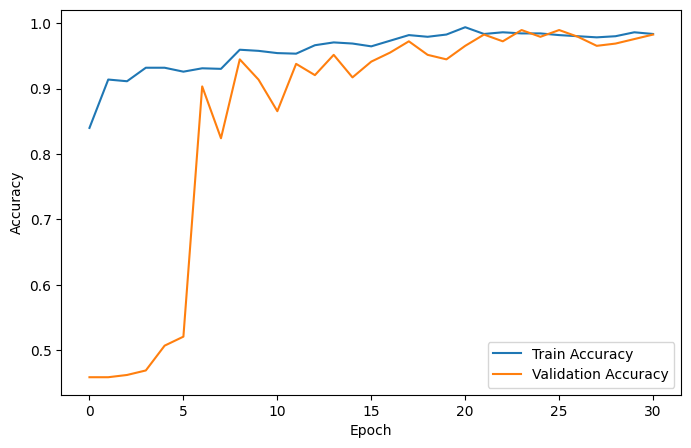

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(eye_history.history['accuracy'],label='Train Accuracy')
plt.plot(eye_history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Training Loss (Eye CNN)

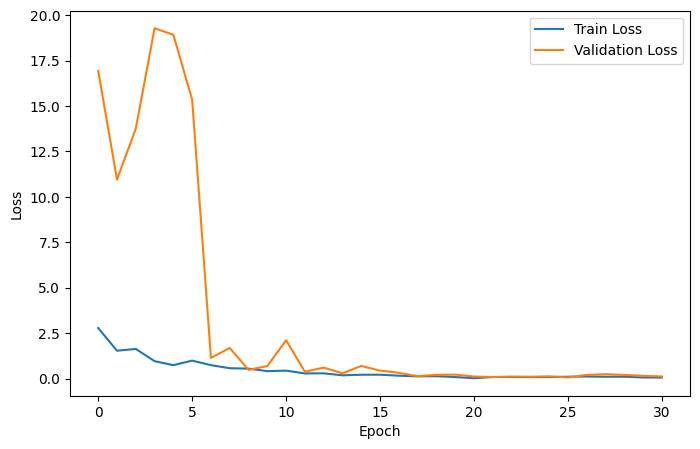

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(eye_history.history['loss'],label='Train Loss')
plt.plot(eye_history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Plot Training Accuracy (Mouth CNN)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mouth_history.history['accuracy'], label='Train Accuracy')
plt.plot(mouth_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Mouth CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Training Loss (Mouth CNN)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mouth_history.history['loss'], label='Train Loss')
plt.plot(mouth_history.history['val_loss'], label='Validation Loss')

plt.title("Mouth CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# 👇👇👇Phase 4: Model Evaluation👇👇👇

## Part A: Eye Model Evaluation

Step 1: Import Libraries

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

Step 2: Predict on Test Dataset

In [ ]:
eye_pred_prob = eye_model.predict(eye_test)

eye_pred = (eye_pred_prob > 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


Step 3: Extract True Labels

In [ ]:
eye_true = np.concatenate([y for x, y in eye_test], axis=0)


Step 4: Calculate Accuracy

In [ ]:
eye_accuracy = accuracy_score(eye_true, eye_pred)

print("Accuracy :", eye_accuracy)

print(eye_history.history['accuracy'][-1])
print(eye_history.history['val_accuracy'][-1])

Accuracy : 0.4586206896551724


NameError: name 'eye_history' is not defined

In [ ]:
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
results = eye_model.evaluate(eye_test)

print(results)

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9897 - loss: 0.0594 - precision: 1.0000 - recall: 0.9809
[0.05944032967090607, 0.9896551966667175, 1.0, 0.9808917045593262]


Step 5: Calculate Precision

In [ ]:
eye_precision = precision_score(eye_true, eye_pred)

print("Precision :", eye_precision)

Precision : 0.6428571428571429


Step 6: Calculate Recall

In [ ]:
eye_recall = recall_score(eye_true, eye_pred)

print("Recall :", eye_recall)

Recall : 0.05732484076433121


Step 7: Calculate F1 Score

In [ ]:
eye_f1 = f1_score(eye_true, eye_pred)

print("F1 Score :", eye_f1)

F1 Score : 0.10526315789473684


Step 8: Confusion Matrix

In [ ]:
eye_cm = confusion_matrix(eye_true, eye_pred)

print(eye_cm)

[[128   5]
 [148   9]]


In [ ]:
loss, acc = eye_model.evaluate(eye_test)

print("Keras Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9897 - loss: 0.0594
Keras Accuracy: 0.9896551966667175


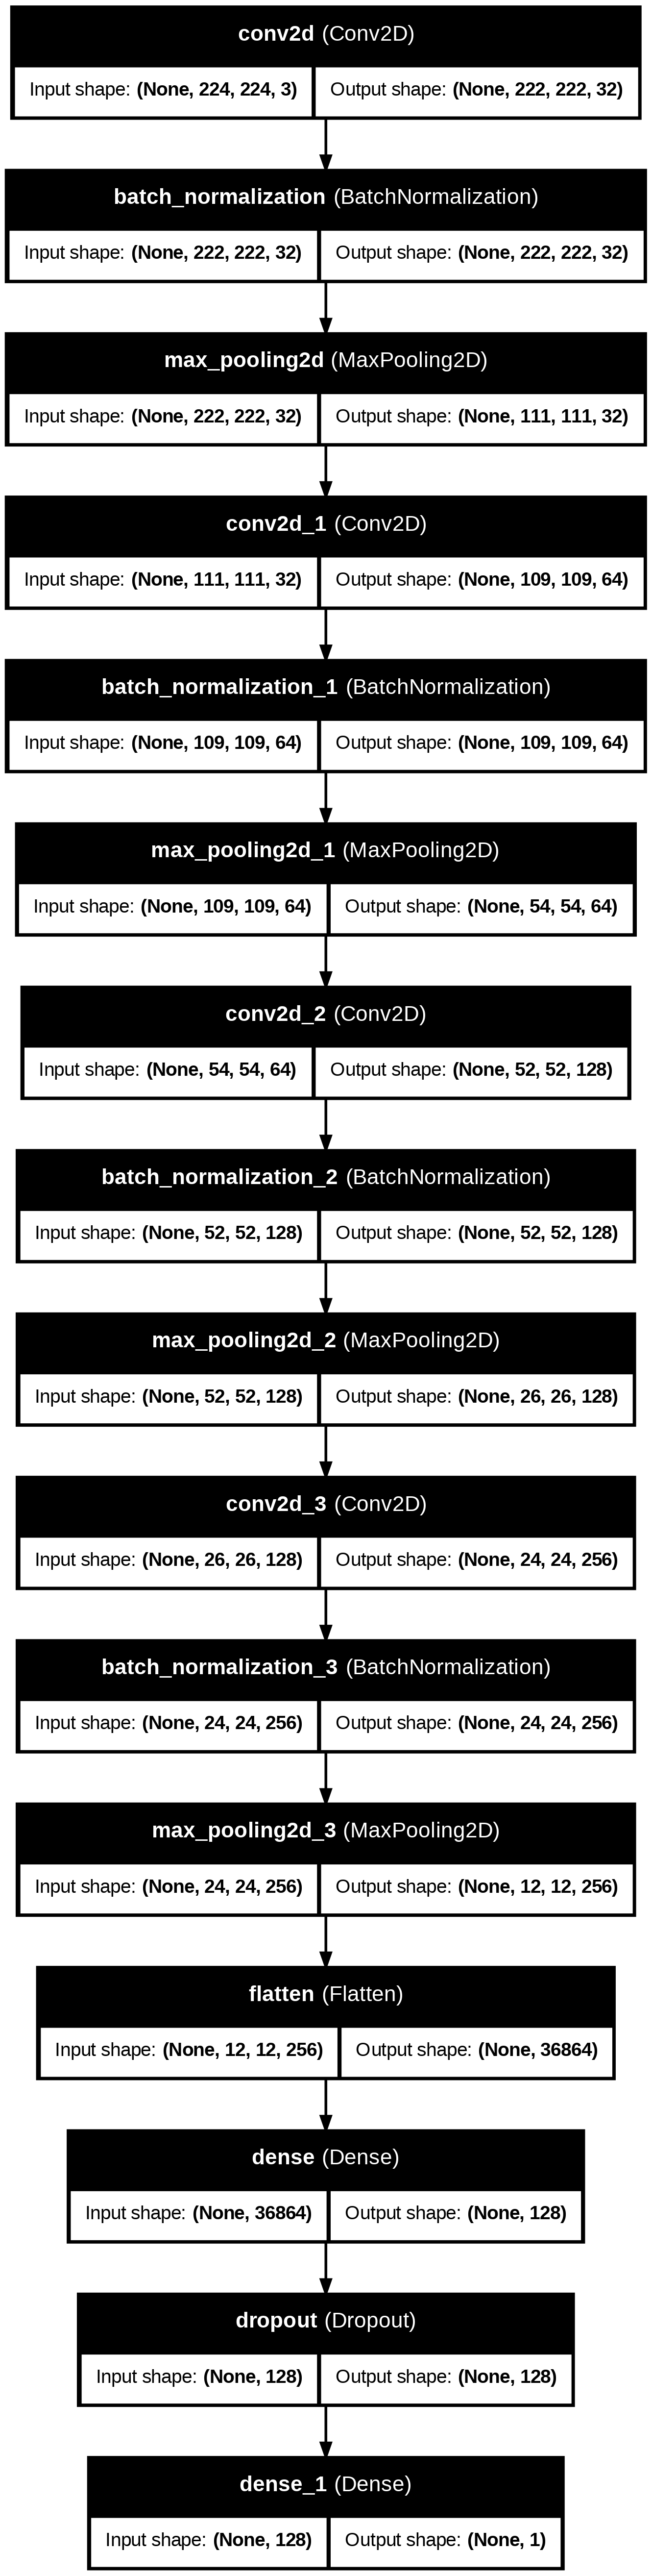

In [ ]:
tf.keras.utils.plot_model(eye_model, show_shapes=True, show_layer_names=True, to_file="eye_model_arch.png")


## Part B: Mouth Model Evaluation

Step 1: Predict

In [ ]:
mouth_pred_prob = mouth_model.predict(mouth_test)

mouth_pred = (mouth_pred_prob > 0.5).astype(int)

Step 2: True Labels

In [ ]:
mouth_true = np.concatenate([y for x, y in mouth_test], axis=0)

Step 3: Accuracy

In [ ]:
mouth_accuracy = accuracy_score(mouth_true, mouth_pred)

print("Accuracy :", mouth_accuracy)

Step 4: Precision

In [ ]:
mouth_precision = precision_score(mouth_true, mouth_pred)

print("Precision :", mouth_precision)

Step 5: Recall

In [ ]:
mouth_recall = recall_score(mouth_true, mouth_pred)

print("Recall :", mouth_recall)

Step 6: F1 Score

In [ ]:
mouth_f1 = f1_score(mouth_true, mouth_pred)

print("F1 Score :", mouth_f1)

Step 7: Confusion Matrix

In [ ]:
mouth_cm = confusion_matrix(mouth_true, mouth_pred)

print(mouth_cm)

## Display All Metrics Together

### Eye Model

In [ ]:
print("Eye Model Performance")

print("Accuracy :", eye_accuracy)
print("Precision :", eye_precision)
print("Recall :", eye_recall)
print("F1 Score :", eye_f1)
print("Confusion Matrix")

print(eye_cm)

### Mouth Model

In [ ]:
print("Mouth Model Performance")

print("Accuracy :", mouth_accuracy)
print("Precision :", mouth_precision)
print("Recall :", mouth_recall)
print("F1 Score :", mouth_f1)
print("Confusion Matrix")

print(mouth_cm)